[*********************100%***********************]  9 of 9 completed



=== Regime Summary ===
         returns  volatility  inflation  yield_spread
Regime                                               
0      -4.200955   12.156333   0.143285      0.960571
1       4.936529   12.587977   1.423457      0.873990
2       1.063266    3.572634   0.314844      1.047622


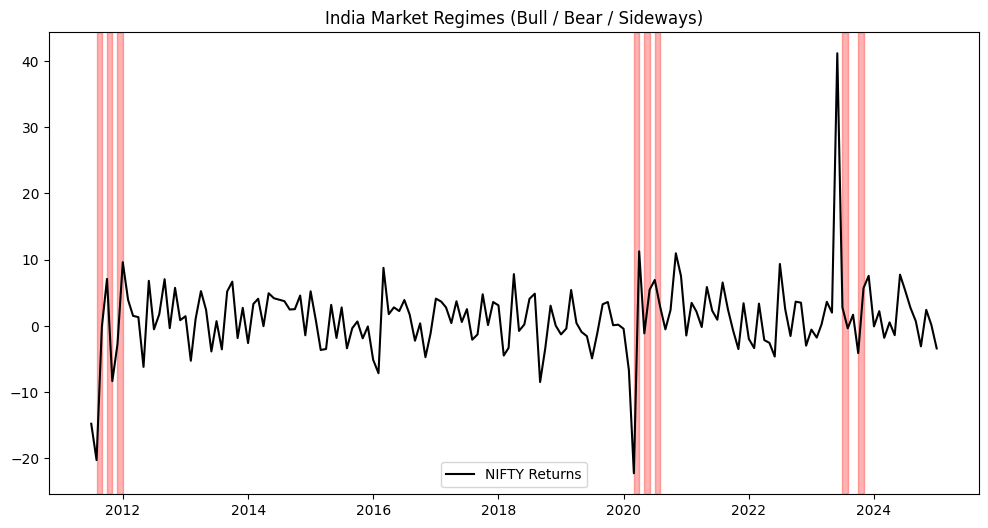

In [10]:
# ================================
# INDIA MARKET REGIME DETECTION
# (Bullish / Bearish / Sideways)
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# ---- 1. Load YOUR macro dataset ----
# Make sure "india_market_macro.csv" is in your directory
df = pd.read_csv("india_market_macro.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# ---- 2. Download NIFTY data ----
nifty_sectoral_indices = [
    "^CNXAUTO",     # Nifty Auto
    "^NSEBANK",     # Nifty Bank
    "^CNXIT",       # Nifty IT
    "^CNXFMCG",     # Nifty FMCG
    "^CNXMEDIA",    # Nifty Media
    "^CNXMETAL",    # Nifty Metal
    "^CNXREALTY",   # Nifty Realty
    "^CNXPHARMA",   # Nifty Pharma
    "^CNXFIN"   # Nifty Financial Services
]
nifty = yf.download(nifty_sectoral_indices, start="2010-01-01", interval="1mo")

# FIX: Isolate the "Close" prices. This returns a DataFrame where columns are the tickers.
nifty = nifty["Close"]

# FIX: Since the HMM logic expects a single "NIFTY" column, average the sectors 
# to create an equally weighted composite market index.
nifty = nifty.mean(axis=1).to_frame(name="NIFTY")

# Fix index
nifty.index = pd.to_datetime(nifty.index)
nifty = nifty.resample("MS").first()

# ---- 3. Merge datasets ----
df = df.join(nifty, how="inner")

# ---- 4. Create Features ----
df["returns"] = np.log(df["NIFTY"]).diff() * 100
df["volatility"] = df["returns"].rolling(6).std()

df["inflation"] = np.log(df["CPI"]).diff() * 100
df["yield_spread"] = df["GS10"] - df["TBILL3M"]

data = df[["returns", "volatility", "inflation", "yield_spread"]].dropna()

# ---- 5. Standardize ----
scaler = StandardScaler()
X = scaler.fit_transform(data)

# ---- 6. Fit HMM (3 regimes) ----
model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

# ---- 7. Predict Regimes ----
data["Regime"] = model.predict(X)

# ---- 8. Interpret Regimes ----
summary = data.groupby("Regime").mean()
print("\n=== Regime Summary ===")
print(summary)

# Label regimes
def classify(row):
    if row["returns"] > 0.5 and row["volatility"] < 2:
        return "Bullish"
    elif row["returns"] < 0 and row["volatility"] > 2:
        return "Bearish"
    else:
        return "Sideways"

regime_labels = summary.apply(classify, axis=1).to_dict()
data["Regime_Label"] = data["Regime"].map(regime_labels)

# ---- 9. Plot ----
plt.figure(figsize=(12,6))
plt.plot(data.index, data["returns"], label="NIFTY Returns", color="black")

# FIX: Added a slight width to axvspan using DateOffset so the highlights actually render
for i in range(len(data)):
    end_date = data.index[i] + pd.DateOffset(months=1)
    if data["Regime_Label"].iloc[i] == "Bearish":
        plt.axvspan(data.index[i], end_date, color='red', alpha=0.3)
    elif data["Regime_Label"].iloc[i] == "Bullish":
        plt.axvspan(data.index[i], end_date, color='green', alpha=0.2)

plt.title("India Market Regimes (Bull / Bear / Sideways)")
plt.legend()
plt.show()


=== Regime Counts ===
Regime
2    144
1     11
0      8
Name: count, dtype: int64

Number of regime switches: 21

=== Average Duration (months) ===
Regime
0     1.0
1     1.1
2    48.0
Name: Duration, dtype: float64

=== Transition Matrix ===
              0         1             2
0  3.165172e-08  1.000000  4.051646e-34
1  6.344977e-01  0.092696  2.728067e-01
2  6.950928e-03  0.007089  9.859602e-01


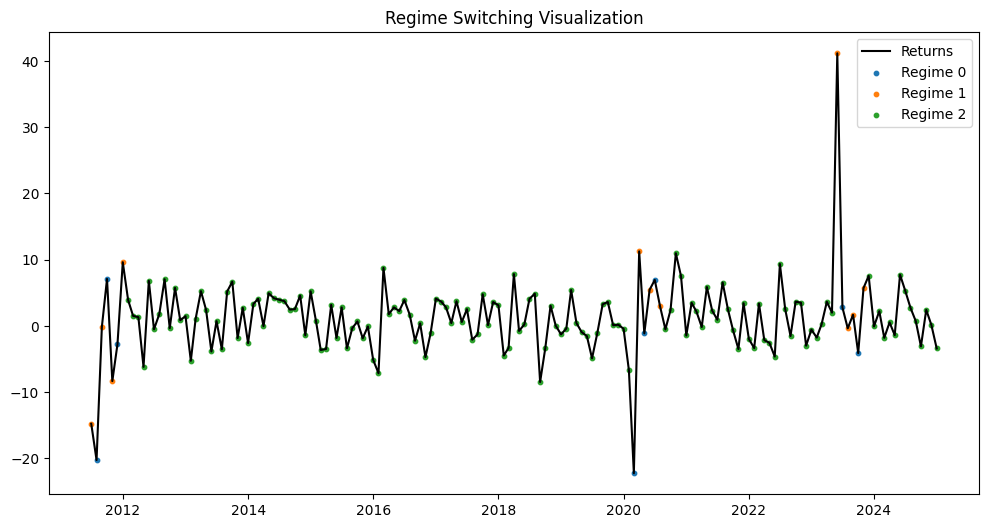

In [8]:
# ================================
# REGIME SWITCHING DIAGNOSTICS
# ================================

# ---- 1. Count how often each regime appears ----
print("\n=== Regime Counts ===")
print(data["Regime"].value_counts())

# ---- 2. Number of switches ----
switches = (data["Regime"] != data["Regime"].shift(1)).sum()
print("\nNumber of regime switches:", switches)

# ---- 3. Average duration of each regime ----
durations = []
current_regime = data["Regime"].iloc[0]
length = 1

for r in data["Regime"].iloc[1:]:
    if r == current_regime:
        length += 1
    else:
        durations.append((current_regime, length))
        current_regime = r
        length = 1

durations.append((current_regime, length))

dur_df = pd.DataFrame(durations, columns=["Regime", "Duration"])

print("\n=== Average Duration (months) ===")
print(dur_df.groupby("Regime")["Duration"].mean())

# ---- 4. Transition matrix ----
print("\n=== Transition Matrix ===")
print(pd.DataFrame(model.transmat_))

# ---- 5. Plot regimes over time (clear switching view) ----
plt.figure(figsize=(12,6))

plt.plot(data.index, data["returns"], color="black", label="Returns")

colors = ["green", "red", "blue"]

for i in range(model.n_components):
    plt.scatter(
        data.index[data["Regime"] == i],
        data["returns"][data["Regime"] == i],
        label=f"Regime {i}",
        s=10
    )

plt.title("Regime Switching Visualization")
plt.legend()
plt.show()

[*********************100%***********************]  9 of 9 completed



  PROCESSING SECTOR: ^CNXAUTO

--- ^CNXAUTO Regime Summary ---
          returns  volatility  inflation  yield_spread
Regime                                                
0      -26.800110   13.477265   0.111091      0.427773
1       10.101670   20.632042   0.914169      0.708366
2        1.077791    5.635611   0.321707      1.042767

--- Regime Counts ---
Regime_Label
Sideways    135
Bearish       2
Name: count, dtype: int64

Number of regime switches: 4

--- Average Duration (months) ---
Regime_Label
Bearish      2.0
Sideways    45.0
Name: Duration, dtype: float64


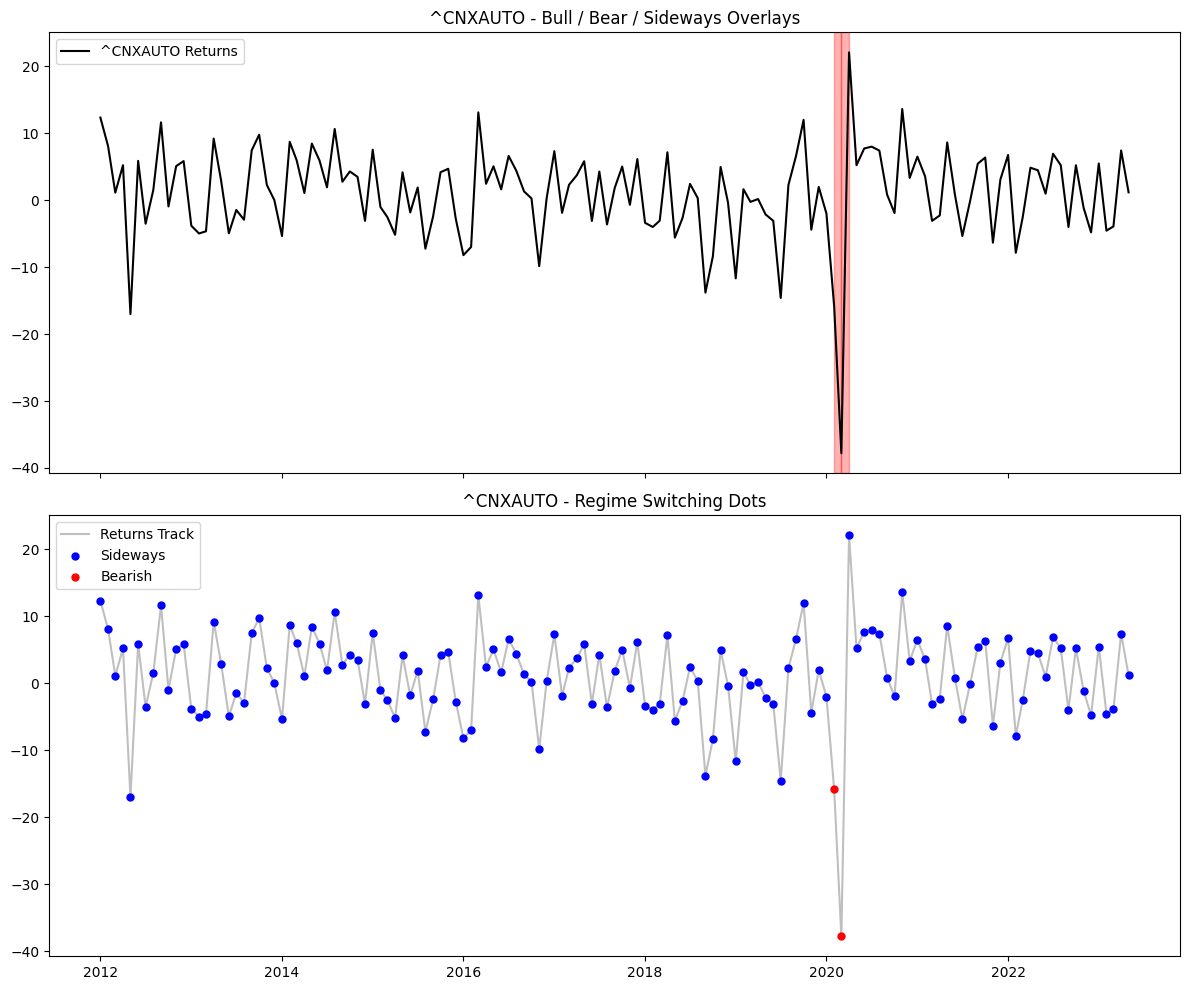


  PROCESSING SECTOR: ^CNXFIN
Not enough data to model ^CNXFIN. Skipping...

  PROCESSING SECTOR: ^CNXFMCG

--- ^CNXFMCG Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0       0.387549    3.422533   0.434020      0.908946
1       1.372162    3.188680   0.593297      1.032460
2       1.353922    5.123518   0.276517      1.062502

--- Regime Counts ---
Regime_Label
Sideways    143
Name: count, dtype: int64

Number of regime switches: 84

--- Average Duration (months) ---
Regime_Label
Sideways    1.702381
Name: Duration, dtype: float64


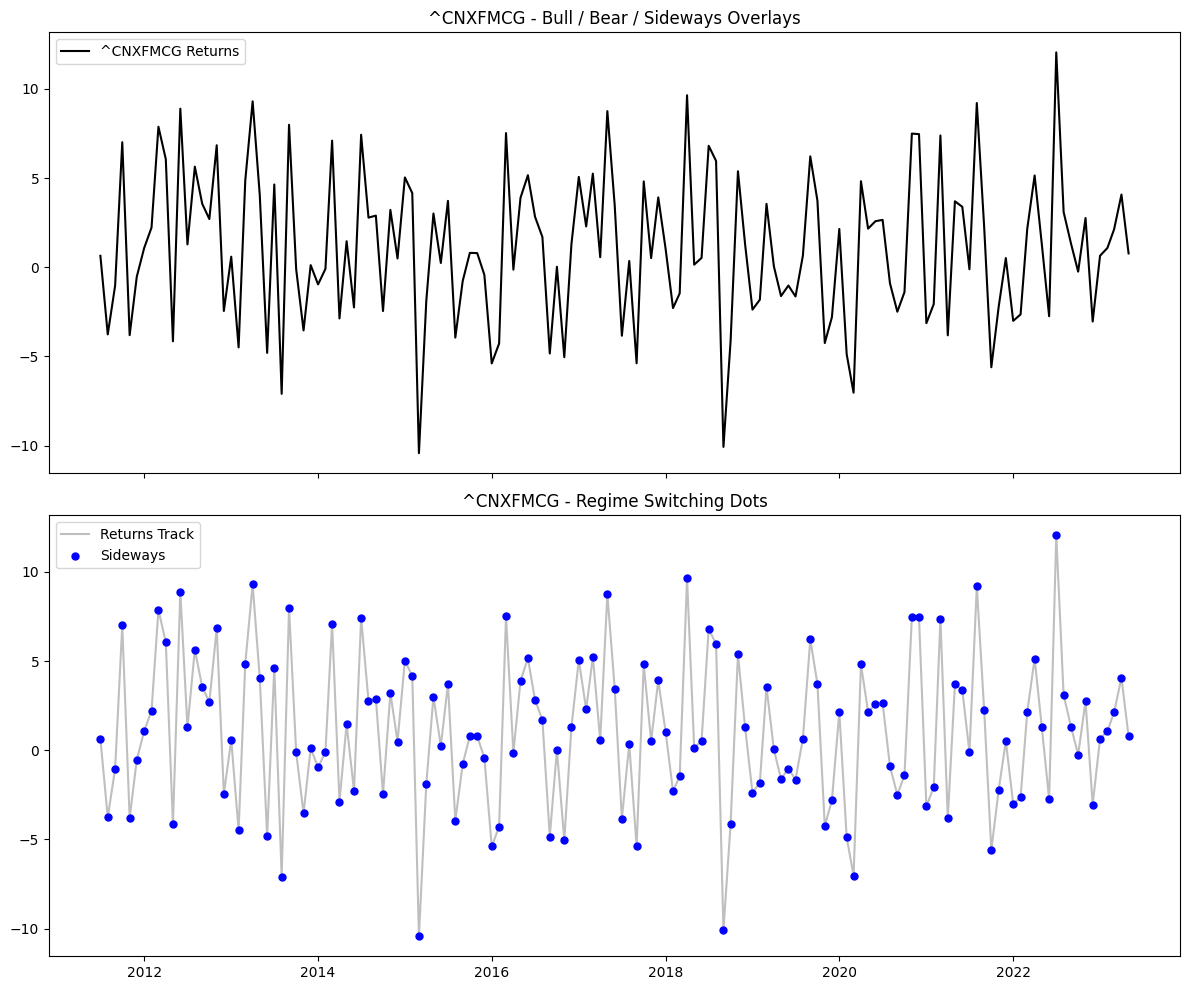


  PROCESSING SECTOR: ^CNXIT

--- ^CNXIT Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0       2.405071    6.020288   0.266225      0.882851
1       4.825886    5.698083   0.363951      0.935512
2      -3.396627    5.535480   0.498466      1.251948

--- Regime Counts ---
Regime_Label
Sideways    105
Bearish      58
Name: count, dtype: int64

Number of regime switches: 138

--- Average Duration (months) ---
Regime_Label
Bearish     1.757576
Sideways    1.000000
Name: Duration, dtype: float64


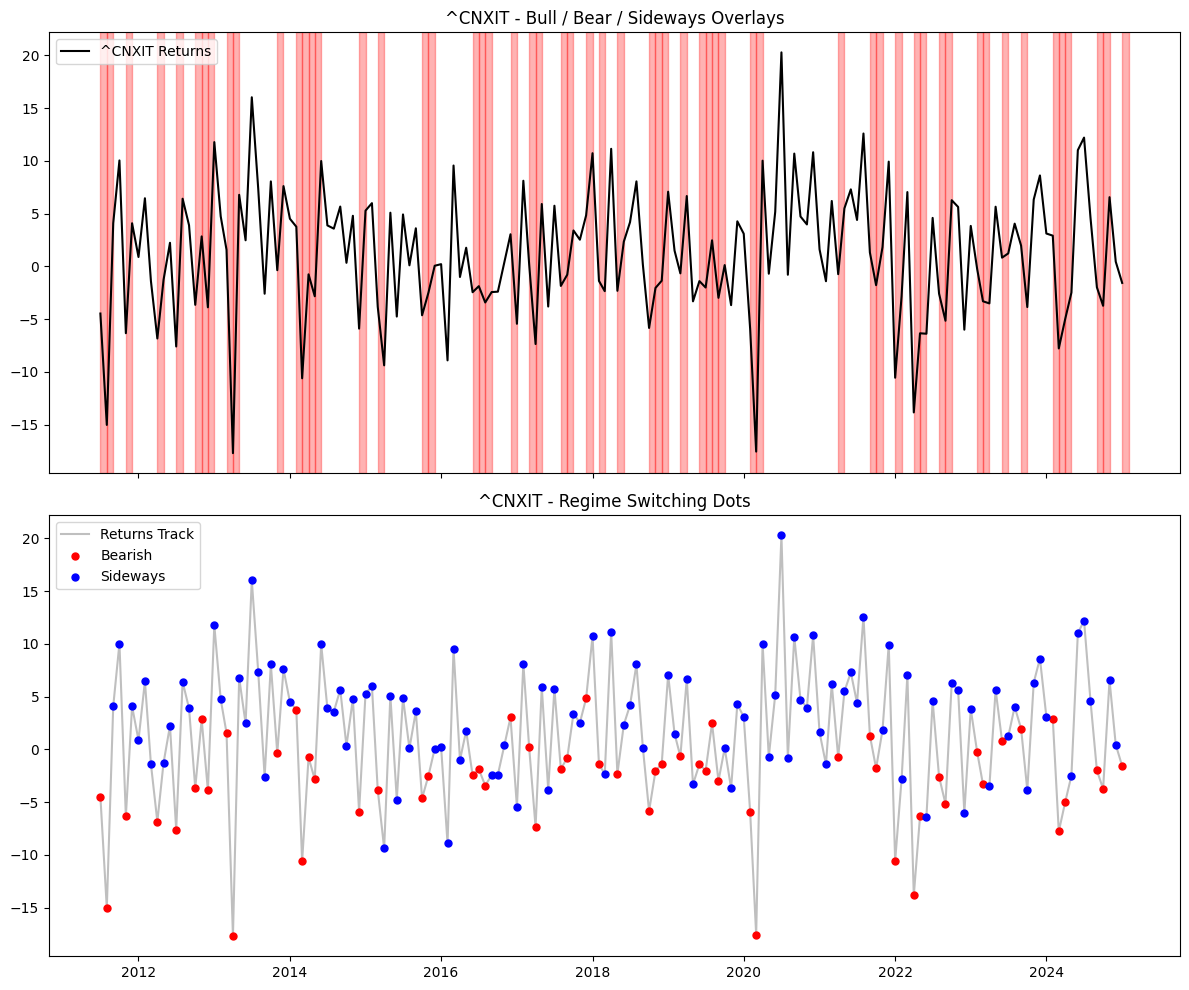


  PROCESSING SECTOR: ^CNXMEDIA

--- ^CNXMEDIA Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0       7.803406   14.001093   0.695568      0.959557
1      -5.558176   12.084549   0.484615      1.077163
2       0.303870    5.543063   0.282458      1.022040

--- Regime Counts ---
Regime_Label
Sideways    118
Bearish      18
Name: count, dtype: int64

Number of regime switches: 35

--- Average Duration (months) ---
Regime_Label
Bearish     1.058824
Sideways    6.555556
Name: Duration, dtype: float64


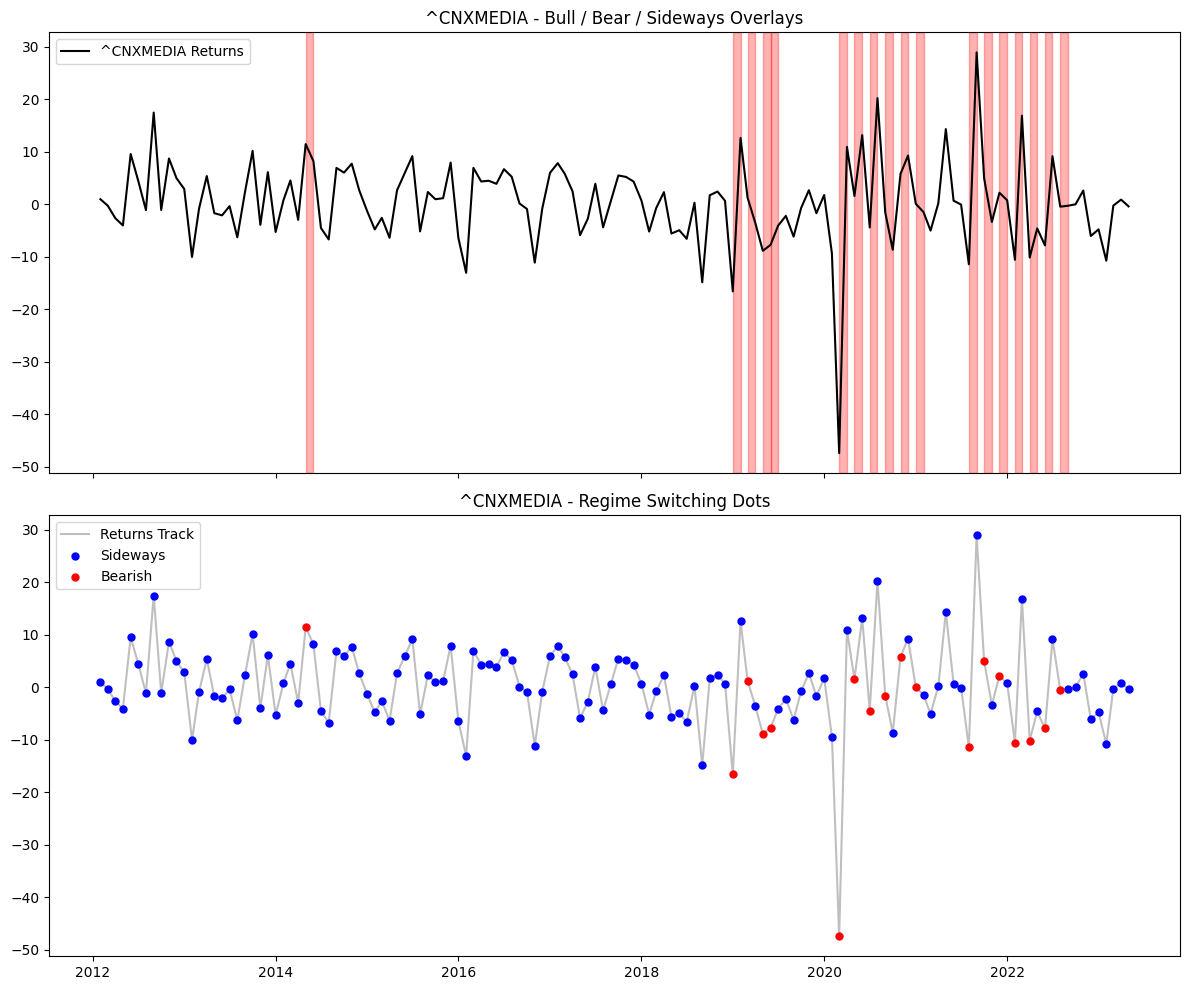


  PROCESSING SECTOR: ^CNXMETAL

--- ^CNXMETAL Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0       1.050499   10.296818   0.493741      0.966505
1       9.633176   13.607711   1.198953      0.976192
2      -1.154551    6.154094   0.101593      1.062869

--- Regime Counts ---
Regime_Label
Bearish     77
Sideways    60
Name: count, dtype: int64

Number of regime switches: 22

--- Average Duration (months) ---
Regime_Label
Bearish     12.833333
Sideways     3.750000
Name: Duration, dtype: float64


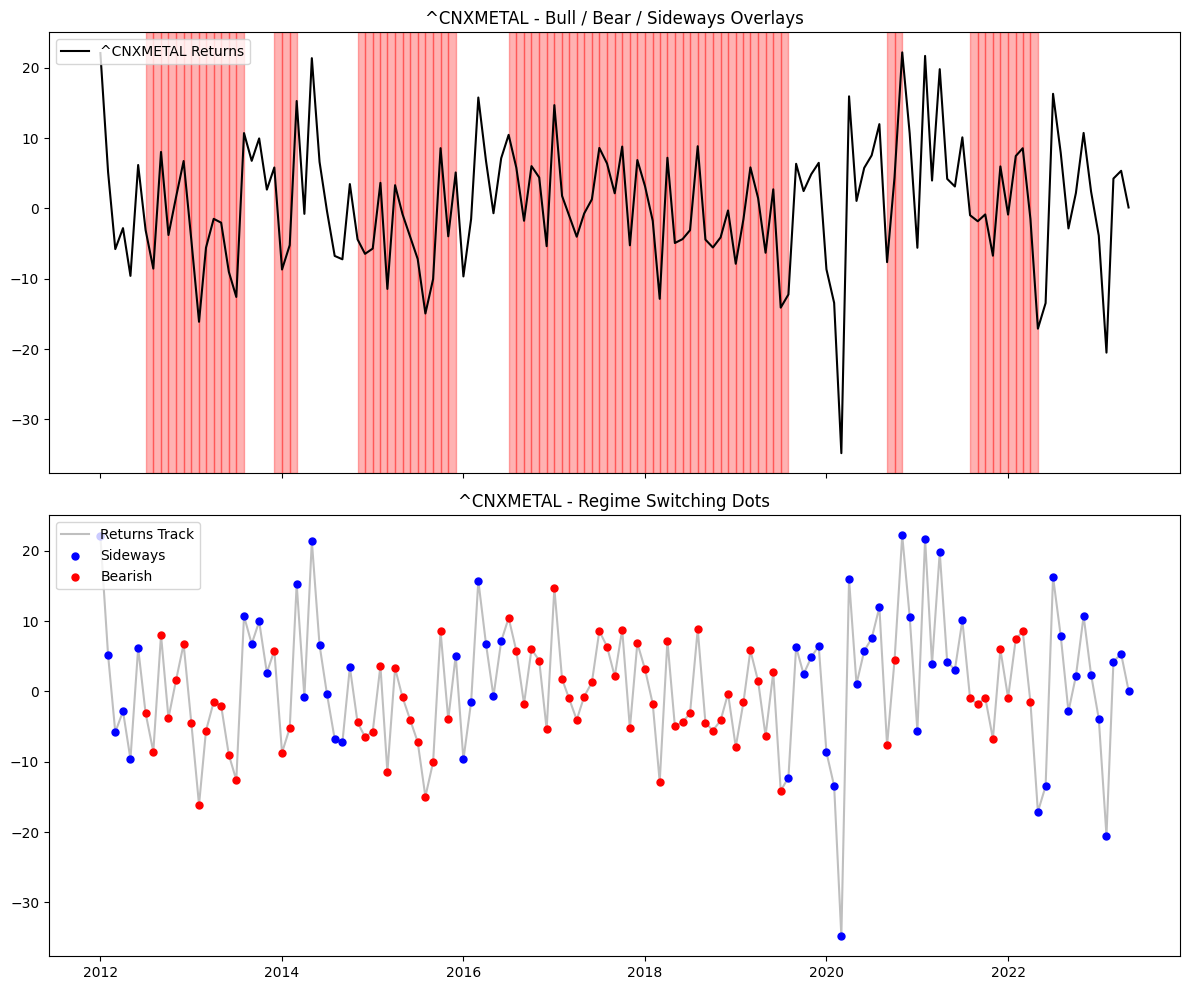


  PROCESSING SECTOR: ^CNXPHARMA

--- ^CNXPHARMA Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0      -4.165324    6.674441   0.647467      1.342124
1       3.055478    7.076785   0.185765      0.718122
2       1.348373    3.936165   0.384298      1.061581

--- Regime Counts ---
Regime_Label
Sideways    140
Bearish      23
Name: count, dtype: int64

Number of regime switches: 55

--- Average Duration (months) ---
Regime_Label
Bearish     1.000
Sideways    4.375
Name: Duration, dtype: float64


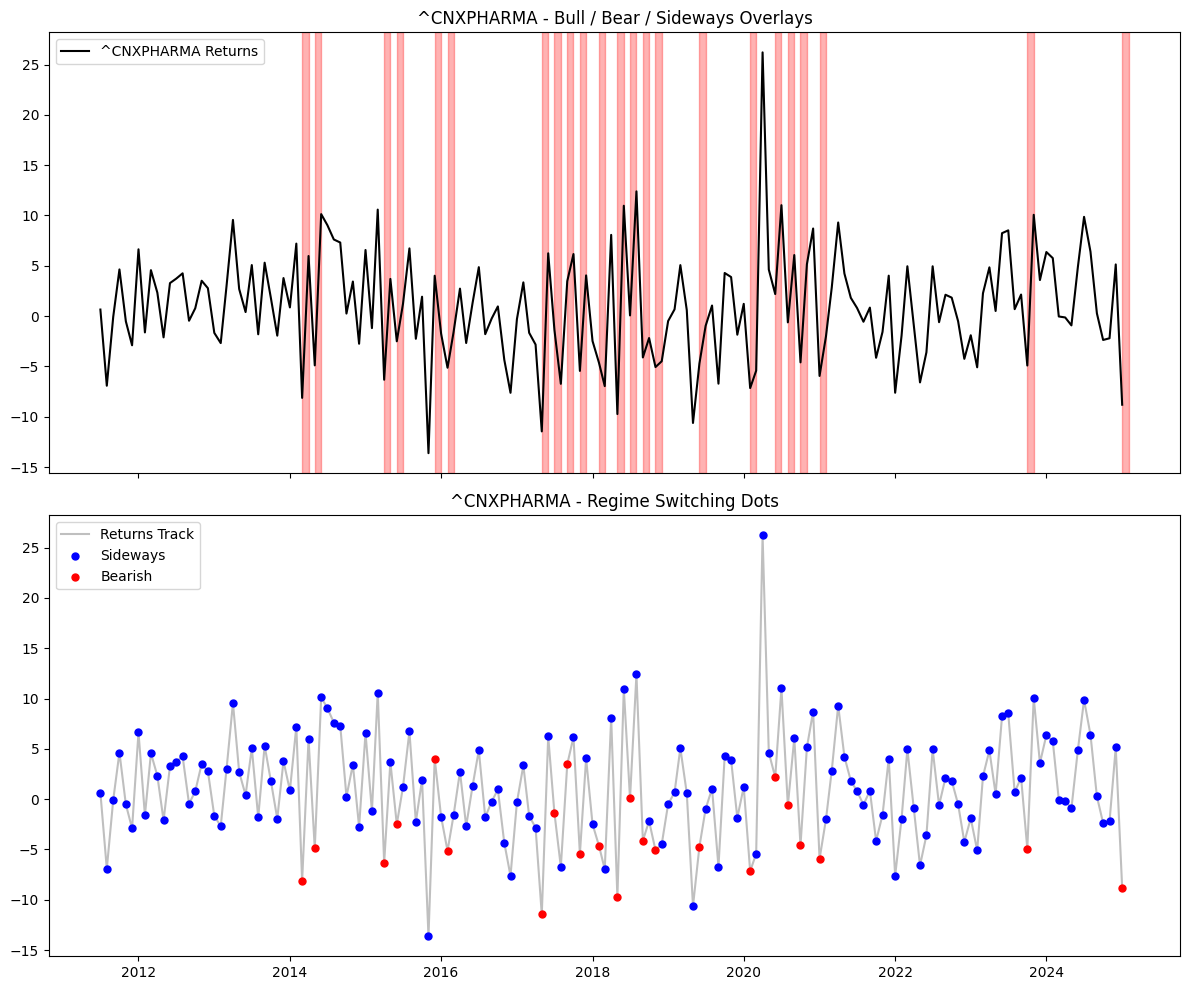


  PROCESSING SECTOR: ^CNXREALTY

--- ^CNXREALTY Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0       4.523243   14.310000   1.103379      1.051106
1      -2.099465   14.355019   0.318044      0.874066
2      -0.068924    7.825096   0.236807      1.034662

--- Regime Counts ---
Regime_Label
Bearish     119
Sideways     24
Name: count, dtype: int64

Number of regime switches: 56

--- Average Duration (months) ---
Regime_Label
Bearish     3.71875
Sideways    1.00000
Name: Duration, dtype: float64


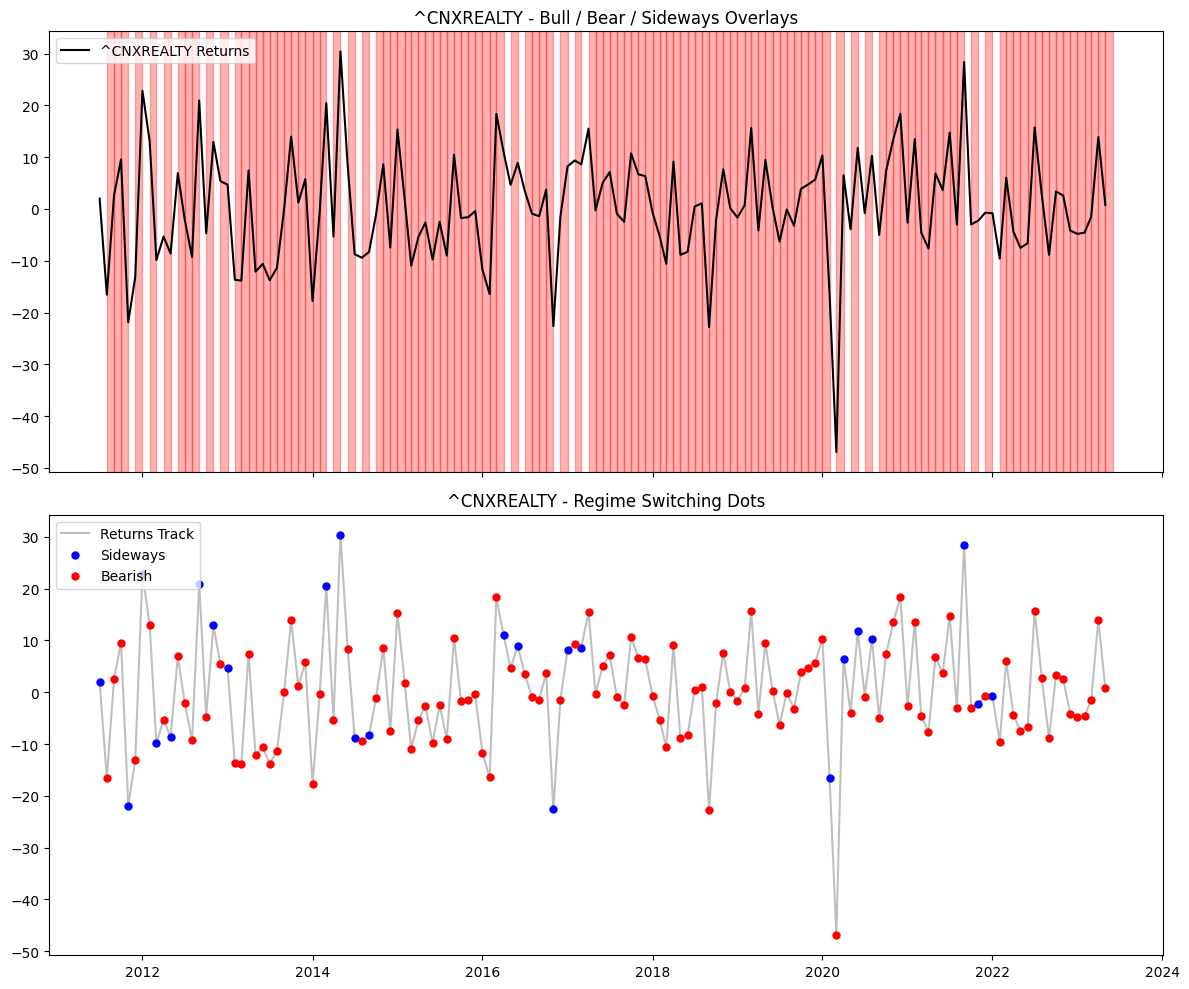


  PROCESSING SECTOR: ^NSEBANK

--- ^NSEBANK Regime Summary ---
         returns  volatility  inflation  yield_spread
Regime                                               
0       0.831198    5.134615   0.264191      1.114850
1       0.083399    4.882440   0.346595      0.977947
2       2.206624   11.430351   0.600727      0.987460

--- Regime Counts ---
Regime_Label
Sideways    163
Name: count, dtype: int64

Number of regime switches: 125

--- Average Duration (months) ---
Regime_Label
Sideways    1.304
Name: Duration, dtype: float64


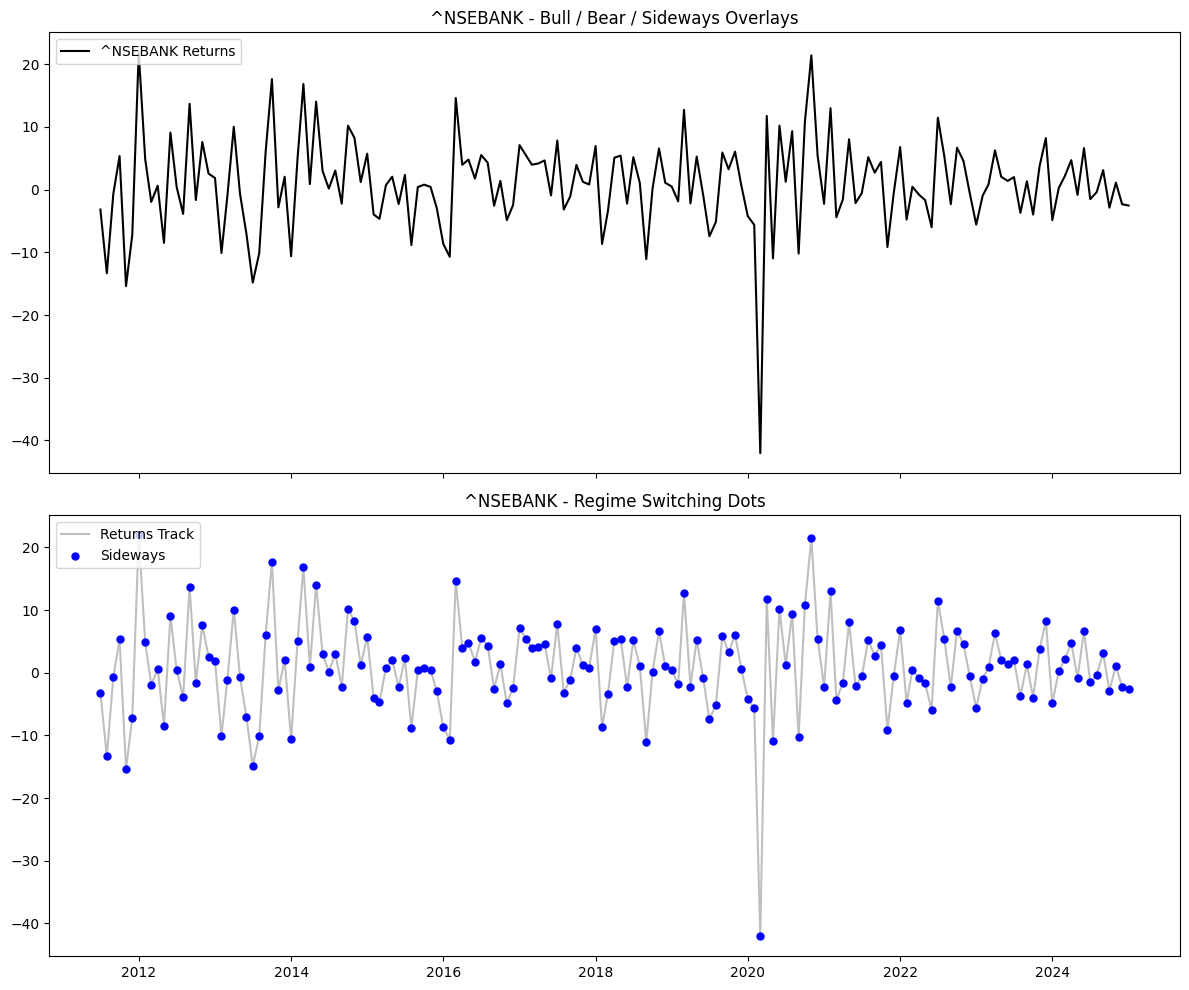


All sectors processed successfully.


In [ ]:
# ==========================================
# SECTORAL MARKET REGIME DETECTION & DIAGNOSTICS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# ---- 1. Load macro dataset ----
df_macro = pd.read_csv("india_market_macro.csv", parse_dates=["Date"])
df_macro.set_index("Date", inplace=True)

# Pre-calculate macro features (since they apply to all sectors)
df_macro["inflation"] = np.log(df_macro["CPI"]).diff() * 100
df_macro["yield_spread"] = df_macro["GS10"] - df_macro["TBILL3M"]

# ---- 2. Download NIFTY sectoral data ----
nifty_sectoral_indices = [
    "^CNXAUTO",     # Nifty Auto
    "^NSEBANK",     # Nifty Bank
    "^CNXIT",       # Nifty IT
    "^CNXFMCG",     # Nifty FMCG
    "^CNXMEDIA",    # Nifty Media
    "^CNXMETAL",    # Nifty Metal
    "^CNXREALTY",   # Nifty Realty
    "^CNXPHARMA",   # Nifty Pharma
    "^CNXFIN"       # Nifty Financial Services
]
nifty = yf.download(nifty_sectoral_indices, start="2010-01-01", interval="1d")

# Isolate "Close" prices
nifty = nifty["Close"]

# Fix index
nifty.index = pd.to_datetime(nifty.index)
nifty = nifty.resample("MS").first()

# ---- 3. Loop Through Each Sector ----
# We will store the resulting dataframes in a dictionary just in case you need them later
sector_results = {}

for sector in nifty.columns:
    print("\n" + "="*50)
    print(f"  PROCESSING SECTOR: {sector}")
    print("="*50)
    
    # Isolate sector data and merge with macro
    sector_price = nifty[[sector]].rename(columns={sector: "Price"})
    df = sector_price.join(df_macro, how="inner")
    
    # ---- 4. Create Sector-Specific Features ----
    df["returns"] = np.log(df["Price"]).diff() * 100
    df["volatility"] = df["returns"].rolling(6).std()
    
    data = df[["returns", "volatility", "inflation", "yield_spread"]].dropna()
    
    if len(data) < 10:
        print(f"Not enough data to model {sector}. Skipping...")
        continue
        
    # ---- 5. Standardize ----
    scaler = StandardScaler()
    X = scaler.fit_transform(data)
    
    # ---- 6. Fit HMM (3 regimes) ----
    model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )
    model.fit(X)
    
    # ---- 7. Predict Regimes ----
    data["Regime"] = model.predict(X)
    
    # ---- 8. Interpret Regimes ----
    summary = data.groupby("Regime").mean()
    
    # Label regimes dynamically
    def classify(row):
        if row["returns"] > 0.5 and row["volatility"] < 2:
            return "Bullish"
        elif row["returns"] < 0 and row["volatility"] > 2:
            return "Bearish"
        else:
            return "Sideways"

    regime_labels = summary.apply(classify, axis=1).to_dict()
    data["Regime_Label"] = data["Regime"].map(regime_labels)
    
    # Save the processed data back to our dictionary
    sector_results[sector] = data
    
    # ---- 9. Diagnostics Output ----
    print(f"\n--- {sector} Regime Summary ---")
    print(summary)
    
    print("\n--- Regime Counts ---")
    print(data["Regime_Label"].value_counts())
    
    switches = (data["Regime"] != data["Regime"].shift(1)).sum()
    print(f"\nNumber of regime switches: {switches}")
    
    # Calculate average duration
    durations = []
    current_regime = data["Regime"].iloc[0]
    length = 1

    for r in data["Regime"].iloc[1:]:
        if r == current_regime:
            length += 1
        else:
            durations.append((current_regime, length))
            current_regime = r
            length = 1
    durations.append((current_regime, length))

    dur_df = pd.DataFrame(durations, columns=["Regime", "Duration"])
    dur_df["Regime_Label"] = dur_df["Regime"].map(regime_labels)
    
    print("\n--- Average Duration (months) ---")
    print(dur_df.groupby("Regime_Label")["Duration"].mean())
    
    # ---- 10. Plot Regimes (Span View) ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    ax1.plot(data.index, data["returns"], label=f"{sector} Returns", color="black", linewidth=1.5)
    for i in range(len(data)):
        end_date = data.index[i] + pd.DateOffset(months=1)
        label_str = data["Regime_Label"].iloc[i]
        
        if label_str == "Bearish":
            ax1.axvspan(data.index[i], end_date, color='red', alpha=0.3)
        elif label_str == "Bullish":
            ax1.axvspan(data.index[i], end_date, color='green', alpha=0.2)
            
    ax1.set_title(f"{sector} - Bull / Bear / Sideways Overlays")
    ax1.legend(loc="upper left")
    
    # ---- 11. Plot Regimes (Scatter Switching View) ----
    ax2.plot(data.index, data["returns"], color="gray", alpha=0.5, label="Returns Track")
    
    # Plot dots colored by regime label
    colors = {"Bullish": "green", "Bearish": "red", "Sideways": "blue"}
    for label in data["Regime_Label"].unique():
        subset = data[data["Regime_Label"] == label]
        ax2.scatter(
            subset.index, 
            subset["returns"], 
            c=colors.get(label, "black"), 
            label=label, 
            s=25,
            zorder=5 # Ensure dots appear on top of the gray line
        )
        
    ax2.set_title(f"{sector} - Regime Switching Dots")
    ax2.legend(loc="upper left")
    
    plt.tight_layout()
    plt.show()

print("\nAll sectors processed successfully.")